# PC Algorithm — AA Smoking Status (Corrected Confounders)

**Purpose:** Run constraint-based causal discovery (PC algorithm) on the 104-SNP
LD-pruned shortlist to identify direct causal parents and upstream hubs relative
to smoking_status.

**Inputs:**
- `shortlist_smoking_80pct_final_corrected.csv` — 104 SNPs from 03_snp_selection
- `checkpoint7_snp_encoded_012.csv` — genotype values for these SNPs
- `checkpoint2_metadata_sample_filtered.csv` — smoking_status outcome

**Key parameters:**
| Parameter | Value |
|---|---|
| alpha (independence test) | 0.001 |
| Test | Fisher's Z |
| Background knowledge | smoking_status forced to tier 1 (cannot cause any SNP) |

**Outputs:**
- `pc_input_smoking_corrected.npy`, `pc_col_names_smoking_corrected.json`
- Edge lists (directed/undirected), ancestral subgraph, direct parents / upstream hubs

**Figures/tables for the paper:** direct-parent count vs upstream-hub count table;
this becomes the sunflower v3 figure.

In [2]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

X_pc_full = np.load(os.path.join(out_dir, "pc_input_smoking_final.npy"))
with open(os.path.join(out_dir, "pc_col_names_smoking_final.json")) as f:
    col_names = json.load(f)

n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")
print("Input shape:", X_pc_full.shape)
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (3036, 10)
n_nodes: 10


Depth=7, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 1545.72it/s]

Completed in 0.2s
Nodes: 10


In [3]:
import networkx as nx

adj = cg.G.graph
n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")

edges_directed = []
edges_undirected = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names[i], col_names[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names[j], col_names[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names[i], col_names[j]))

print(f"Directed edges: {len(edges_directed)}")
print(f"Undirected edges: {len(edges_undirected)}")

direct_parents = set()
for u, v in edges_directed:
    if v == "smoking_status":
        direct_parents.add(u)
for u, v in edges_undirected:
    if "smoking_status" in (u, v):
        direct_parents.add(v if u == "smoking_status" else u)

print(f"\nDirect parents: {len(direct_parents)}")
for p in sorted(direct_parents):
    marker = " *** PPP1R12B ***" if "2277017" in p else ""
    print(f"  {p} → smoking_status{marker}")

G = nx.DiGraph()
G.add_nodes_from(col_names)
G.add_edges_from(edges_directed)
for u, v in edges_undirected:
    G.add_edge(u, v)
    G.add_edge(v, u)

ancestors = nx.ancestors(G, "smoking_status") | {"smoking_status"}
upstream_hubs = ancestors - direct_parents - {"smoking_status"}

print(f"\nTotal ancestral subgraph size: {len(ancestors)}")
print(f"Upstream hubs: {len(upstream_hubs)}")
for h in sorted(upstream_hubs):
    print(f"  {h}")

Directed edges: 8
Undirected edges: 0

Direct parents: 8
  exm-rs7014346-131_B_R_1990484715 → smoking_status
  exm1003257-0_T_F_1922526121 → smoking_status
  exm100944-0_B_R_1921482882 → smoking_status
  exm1245580-0_B_F_2060131617 → smoking_status
  exm1379120-0_T_F_1921625489 → smoking_status
  exm2277017-0_T_R_1989215336 → smoking_status *** PPP1R12B ***
  exm609218-0_B_F_1918575531 → smoking_status
  exm782555-0_B_R_1922302526 → smoking_status

Total ancestral subgraph size: 9
Upstream hubs: 0


In [4]:
import json
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

with open(os.path.join(out_dir, "gene_map_smoking_sensitivity_grch37.json")) as f:
    gene_map_full = json.load(f)

# filter to just the 9 final SNPs
gene_map = {snp: gene_map_full[snp] for snp in ancestors if snp != "smoking_status"}

for snp, gene in gene_map.items():
    print(f"{snp[:35]:37s} -> {gene}")

with open(os.path.join(out_dir, "gene_map_smoking_final_grch37.json"), "w") as f:
    json.dump(gene_map, f)
print("Saved.")

exm1003257-0_T_F_1922526121           -> CELA1
exm782555-0_B_R_1922302526            -> ZNF79
exm1245580-0_B_F_2060131617           -> PRSS54
exm-rs7014346-131_B_R_1990484715      -> CASC8
exm100944-0_B_R_1921482882            -> FLG-AS1
exm609218-0_B_F_1918575531            -> FAM126A
exm2277017-0_T_R_1989215336           -> PPP1R12B
exm1379120-0_T_F_1921625489           -> LAMA3
Saved.


In [6]:
import pandas as pd
import re

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

manifest_df["core_name"] = manifest_df["IlmnID"].map(strip_address_suffix)
position_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo"]]
print("position_lookup rebuilt, shape:", position_lookup.shape)

position_lookup rebuilt, shape: (247894, 2)


In [9]:
import pandas as pd
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
shortlist_100_final = pd.read_csv(os.path.join(out_dir, "shortlist_smoking_100pct_final.csv"))
print("Shortlist loaded:", len(shortlist_100_final))

Shortlist loaded: 9


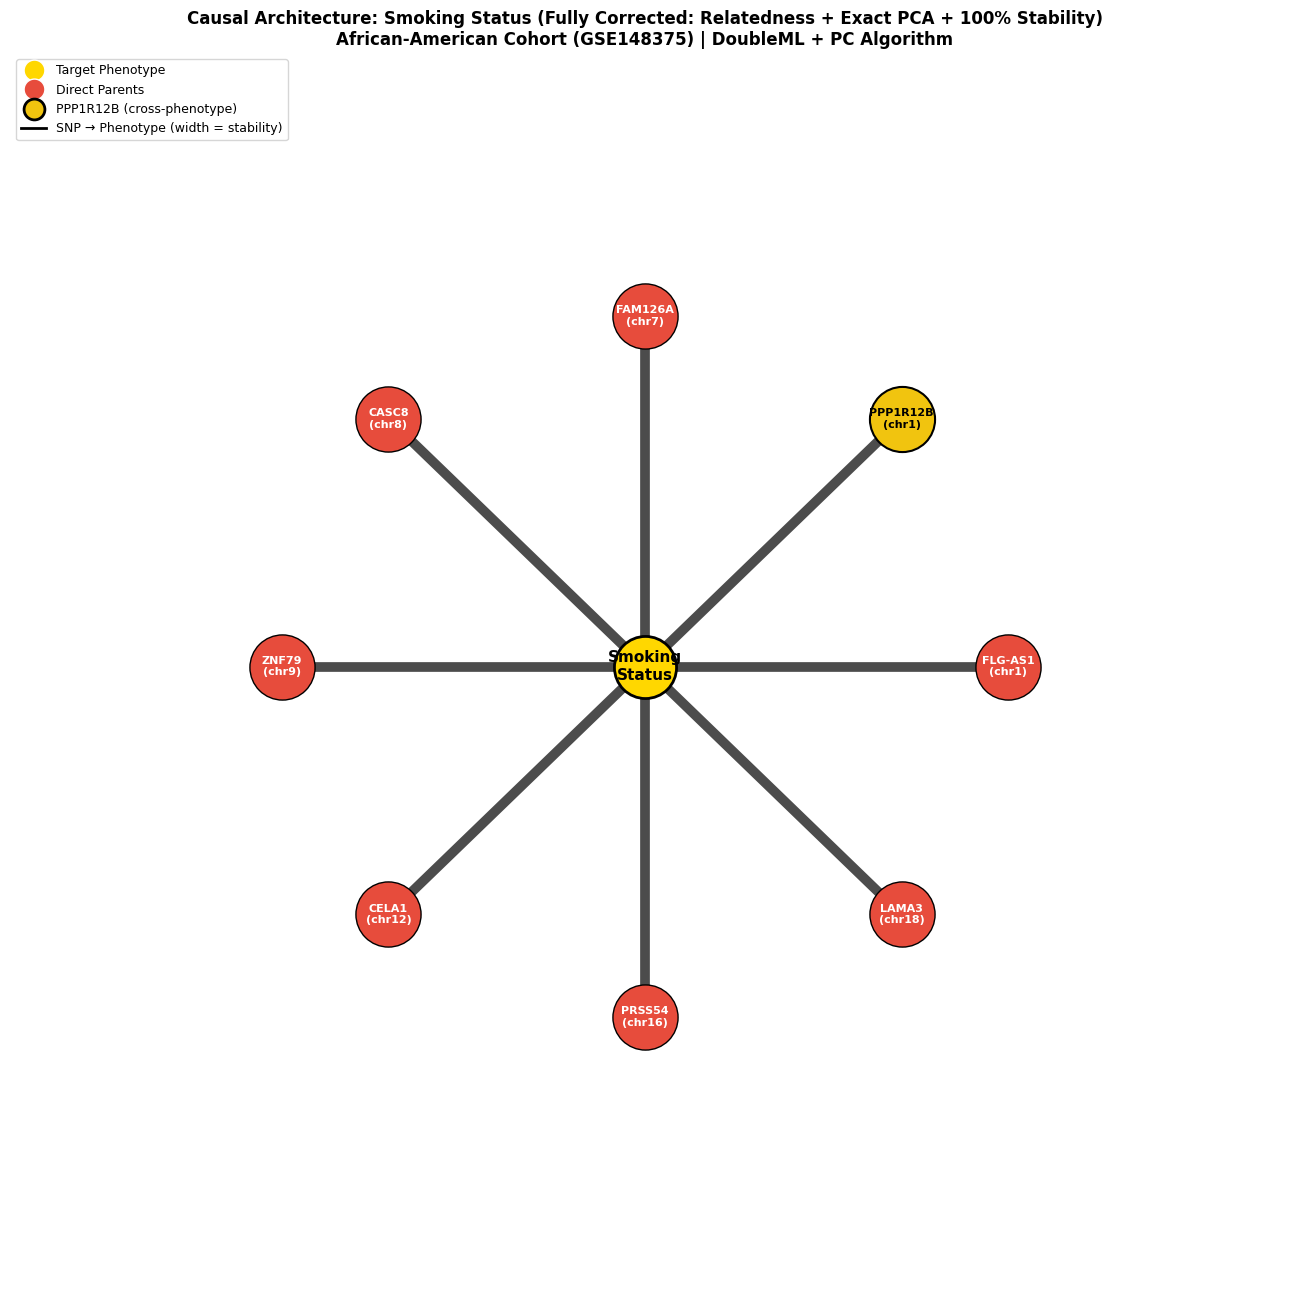

Saved.


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

def make_label_v2(snp_id, gene_map, pos_lookup, strip_fn):
    gene = gene_map.get(snp_id, "?")
    core = strip_fn(snp_id)
    chrom = pos_lookup.loc[core, "Chr"] if core in pos_lookup.index else "?"
    if gene.startswith("ENSG"):
        gene = "ENSG.." + gene[-6:]
    elif gene.startswith("intergenic_chr"):
        gene = "intergenic"
    return f"{gene}\n(chr{chrom})"

def chr_sort_key(snp_id, pos_lookup, strip_fn):
    core = strip_fn(snp_id)
    if core not in pos_lookup.index:
        return (999, 0)
    chrom = pos_lookup.loc[core, "Chr"]
    try:
        chrom_num = int(chrom)
    except ValueError:
        chrom_num = {"X": 23, "Y": 24, "XY": 25, "MT": 26}.get(chrom, 27)
    return (chrom_num, pos_lookup.loc[core, "MapInfo"])

direct_parents_sorted = sorted(direct_parents, key=lambda s: chr_sort_key(s, position_lookup, strip_address_suffix))

stability_map = dict(zip(shortlist_100_final["probe_id"], shortlist_100_final["stability_fraction"]))

fig, ax = plt.subplots(figsize=(13, 13))
center = np.array([0, 0])
ax.scatter(*center, s=2000, c="gold", zorder=5, edgecolors="black", linewidths=2)
ax.text(*center, "Smoking\nStatus", ha="center", va="center", fontsize=11, fontweight="bold", zorder=6)

inner_r = 4
pos = {"smoking_status": center}
for i, snp in enumerate(direct_parents_sorted):
    angle = 2 * np.pi * i / len(direct_parents_sorted)
    pos[snp] = inner_r * np.array([np.cos(angle), np.sin(angle)])

for u, v in edges_directed:
    if u in pos and v in pos:
        width = 1 + 6 * stability_map.get(u, 0.5)
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="black", linewidth=width, zorder=1, alpha=0.7)

for snp in direct_parents_sorted:
    color = "#f1c40f" if "2277017" in snp else "#e74c3c"  # highlight PPP1R12B in a distinct shade
    ax.scatter(*pos[snp], s=2200, c=color, zorder=4, edgecolors="black", linewidths=1.5 if "2277017" in snp else 1)
    label = make_label_v2(snp, gene_map, position_lookup, strip_address_suffix)
    ax.text(*pos[snp], label, ha="center", va="center", fontsize=8, fontweight="bold", color="white" if "2277017" not in snp else "black", zorder=6)

ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axis("off")
ax.set_title("Causal Architecture: Smoking Status (Fully Corrected: Relatedness + Exact PCA + 100% Stability)\nAfrican-American Cohort (GSE148375) | DoubleML + PC Algorithm",
              fontsize=12, fontweight="bold")

legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold', markersize=15, label='Target Phenotype'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=15, label='Direct Parents'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#f1c40f', markersize=15, markeredgewidth=2, markeredgecolor='black', label='PPP1R12B (cross-phenotype)'),
    plt.Line2D([0],[0], color='black', linewidth=2, label='SNP → Phenotype (width = stability)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "sunflower_smoking_AA_final_corrected.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [5]:
import pandas as pd
import numpy as np
import re
import os
import gc

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

encoded_df = pd.read_csv(os.path.join(out_dir, "checkpoint7b_snp_encoded_012_relatedness_filtered.csv"))
probe_id_array = encoded_df["probe_id"].to_numpy()
sample_cols = encoded_df.columns[1:]
sample_ids = sample_cols.tolist()
X_snp_first = encoded_df[sample_cols].to_numpy(dtype=np.int8)
del encoded_df
gc.collect()

manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
non_autosomal = {"X", "Y", "XY", "MT", "0"}
sex_linked_probes = set(manifest_df.loc[manifest_df["Chr"].isin(non_autosomal), "IlmnID"])
sex_linked_core_names = {strip_address_suffix(p) for p in sex_linked_probes}
our_probe_core_names = {strip_address_suffix(p): p for p in probe_id_array}
to_exclude = {our_probe_core_names[c] for c in sex_linked_core_names if c in our_probe_core_names}
del manifest_df
gc.collect()

keep_mask = ~np.isin(probe_id_array, list(to_exclude))
X_auto_int = X_snp_first[keep_mask]
del X_snp_first
gc.collect()

X_auto_64 = X_auto_int.T.astype(np.float64)
del X_auto_int
gc.collect()

p = X_auto_64.mean(axis=0) / 2
denom = np.sqrt(2 * p * (1 - p))
valid_snp_mask = denom > 1e-8
X_standardized = (X_auto_64[:, valid_snp_mask] - 2 * p[valid_snp_mask]) / denom[valid_snp_mask]
del X_auto_64
gc.collect()

probe_ids_valid = probe_id_array[keep_mask][valid_snp_mask]
probe_id_to_idx = {pid: i for i, pid in enumerate(probe_ids_valid)}
print("X_standardized shape:", X_standardized.shape)

meta_df = pd.read_csv(os.path.join(out_dir, "checkpoint2b_metadata_relatedness_filtered.csv"))
meta_df["sample_id"] = meta_df["sample_id"].astype(str)
status_map = meta_df.set_index("sample_id")["smoking_status"]
Y = np.array([1.0 if status_map.get(sid) == "Smoker" else 0.0 for sid in sample_ids])
print("Y distribution:", np.unique(Y, return_counts=True))

X_standardized shape: (3036, 141324)
Y distribution: (array([0., 1.]), array([1577, 1459]))


In [6]:
import pandas as pd
import numpy as np
import json
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

shortlist_80_exploratory = pd.read_csv(os.path.join(out_dir, "shortlist_smoking_80pct_exploratory_final.csv"))
final_ids_exp = shortlist_80_exploratory["probe_id"].tolist()
print("Exploratory SNP count:", len(final_ids_exp))

final_col_indices_exp = [probe_id_to_idx[pid] for pid in final_ids_exp]
X_pc_exp = X_standardized[:, final_col_indices_exp]

col_names_exp = final_ids_exp + ["smoking_status"]
X_pc_full_exp = np.hstack([X_pc_exp, Y.reshape(-1, 1)])

print("PC input shape:", X_pc_full_exp.shape)

np.save(os.path.join(out_dir, "pc_input_smoking_exploratory.npy"), X_pc_full_exp)
with open(os.path.join(out_dir, "pc_col_names_smoking_exploratory.json"), "w") as f:
    json.dump(col_names_exp, f)
print("Saved.")

Exploratory SNP count: 302
PC input shape: (3036, 303)
Saved.


In [7]:
import pandas as pd
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
shortlist_90_final = pd.read_csv(os.path.join(out_dir, "shortlist_smoking_90pct_final.csv"))
print("Loaded:", len(shortlist_90_final))

Loaded: 67


In [8]:
import pandas as pd
import numpy as np
import json
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

final_ids_90 = shortlist_90_final["probe_id"].tolist()
print("Final SNP count:", len(final_ids_90))

final_col_indices_90 = [probe_id_to_idx[pid] for pid in final_ids_90]
X_pc_90 = X_standardized[:, final_col_indices_90]

col_names_90 = final_ids_90 + ["smoking_status"]
Y = np.array([1.0 if s == "Smoker" else 0.0 for s in pd.read_csv(os.path.join(out_dir, "checkpoint2b_metadata_relatedness_filtered.csv")).set_index("sample_id").reindex(sample_ids)["smoking_status"]])
X_pc_full_90 = np.hstack([X_pc_90, Y.reshape(-1, 1)])

print("PC input shape:", X_pc_full_90.shape)

np.save(os.path.join(out_dir, "pc_input_smoking_90pct.npy"), X_pc_full_90)
with open(os.path.join(out_dir, "pc_col_names_smoking_90pct.json"), "w") as f:
    json.dump(col_names_90, f)
print("Saved.")

Final SNP count: 67
PC input shape: (3036, 68)
Saved.


In [9]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
X_pc_full_90 = np.load(os.path.join(out_dir, "pc_input_smoking_90pct.npy"))
with open(os.path.join(out_dir, "pc_col_names_smoking_90pct.json")) as f:
    col_names_90 = json.load(f)

n_nodes = len(col_names_90)
outcome_idx = col_names_90.index("smoking_status")
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names_90]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full_90,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names_90
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


n_nodes: 68


Depth=2, working on node 67: 100%|██████████| 68/68 [00:00<00:00, 440.85it/s] 

KeyboardInterrupt: 

In [10]:
import numpy as np

X_snps_only = X_pc_full_90[:, :-1]  # exclude the smoking_status column
stds = X_snps_only.std(axis=0)

print("Any zero-std SNPs:", (stds == 0).sum())
print("Any NaN in the matrix:", np.isnan(X_snps_only).sum())
print("Min std:", stds.min())

zero_std_indices = np.where(stds == 0)[0]
if len(zero_std_indices) > 0:
    print("\nZero-variance SNPs found at indices:", zero_std_indices)
    for idx in zero_std_indices:
        print(f"  {col_names_90[idx]}")

Any zero-std SNPs: 0
Any NaN in the matrix: 0
Min std: 0.8431061768708062


Depth=2, working on node 67: 100%|██████████| 68/68 [00:18<00:00, 440.85it/s]

In [1]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import networkx as nx
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
X_pc_full = np.load(os.path.join(out_dir, "pc_input_smoking_final.npy"))
with open(os.path.join(out_dir, "pc_col_names_smoking_final.json")) as f:
    col_names = json.load(f)

n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")

def run_pc_get_parents(alpha_val):
    bk = BackgroundKnowledge()
    nodes = [GraphNode(name) for name in col_names]
    for i in range(n_nodes - 1):
        bk.add_node_to_tier(nodes[i], 0)
    bk.add_node_to_tier(nodes[outcome_idx], 1)

    cg = pc(data=X_pc_full, alpha=alpha_val, indep_test=fisherz, stable=True,
            uc_rule=0, uc_priority=2, background_knowledge=bk,
            verbose=False, show_progress=False, node_names=col_names)

    adj = cg.G.graph
    edges_directed, edges_undirected = [], []
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if adj[i,j] == -1 and adj[j,i] == 1:
                edges_directed.append((col_names[i], col_names[j]))
            elif adj[i,j] == 1 and adj[j,i] == -1:
                edges_directed.append((col_names[j], col_names[i]))
            elif adj[i,j] == -1 and adj[j,i] == -1:
                edges_undirected.append((col_names[i], col_names[j]))

    direct_parents = set()
    for u, v in edges_directed:
        if v == "smoking_status":
            direct_parents.add(u)
    for u, v in edges_undirected:
        if "smoking_status" in (u, v):
            direct_parents.add(v if u == "smoking_status" else u)
    return direct_parents

for alpha_val in [0.0001, 0.001, 0.005]:
    parents = run_pc_get_parents(alpha_val)
    print(f"alpha={alpha_val}: {len(parents)} direct parents")
    for p in sorted(parents):
        print(f"    {p}")
    print()

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


alpha=0.0001: 1 direct parents
    exm609218-0_B_F_1918575531

alpha=0.001: 8 direct parents
    exm-rs7014346-131_B_R_1990484715
    exm1003257-0_T_F_1922526121
    exm100944-0_B_R_1921482882
    exm1245580-0_B_F_2060131617
    exm1379120-0_T_F_1921625489
    exm2277017-0_T_R_1989215336
    exm609218-0_B_F_1918575531
    exm782555-0_B_R_1922302526

alpha=0.005: 9 direct parents
    exm-rs7014346-131_B_R_1990484715
    exm1003257-0_T_F_1922526121
    exm100944-0_B_R_1921482882
    exm1245580-0_B_F_2060131617
    exm1379120-0_T_F_1921625489
    exm2277017-0_T_R_1989215336
    exm2941-0_B_R_1919117890
    exm609218-0_B_F_1918575531
    exm782555-0_B_R_1922302526

